# IIoT Intrusion Detection System — N-BaIoT

**Models:** Centralized CNN-GRU · Autoencoder (Anomaly Detection) · Federated CNN-GRU  
**Dataset:** N-BaIoT — real IoT traffic with Mirai and Gafgyt botnet attacks  
**Label scheme:** `0 = Benign`, `1 = Attack (Mirai / Gafgyt)`  

All trained artifacts are saved to `/kaggle/working/` and are available as Kaggle output files.

In [1]:

# ============================================================
# SECTION 0 — Imports
# ============================================================
import os
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, GRU, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# ---- Reproducibility seeds ----
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)


2026-04-01 06:02:18.900454: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775023339.092788      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775023339.146029      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775023339.593958      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775023339.593999      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775023339.594003      17 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


## 1. Load N-BaIoT Dataset

All CSV files are loaded in a single pass. Labels are derived from the filename:
- Files containing `benign` → **0** (Benign)
- All other files → **1** (Attack — Mirai or Gafgyt)

In [2]:

# ---- Auto-detect the N-BaIoT dataset path ----
def find_dataset_path(base='/kaggle/input', keywords=('nbaiot', 'n-baiot', 'n_baiot')):
    """Recursively walk /kaggle/input and return the folder that contains N-BaIoT CSVs."""
    for root, dirs, files in os.walk(base):
        # Check if this folder contains relevant CSVs AND its path matches a keyword
        if any(f.endswith('.csv') for f in files):
            if any(k in root.lower() for k in keywords):
                return root
    return None

DATA_PATH = find_dataset_path()

if DATA_PATH is None:
    print("Could not auto-detect dataset. All paths under /kaggle/input:")
    for root, dirs, files in os.walk('/kaggle/input'):
        for f in files:
            print(' ', os.path.join(root, f))
    raise FileNotFoundError(
        "N-BaIoT dataset not found. Add it via '+ Add Data' in Kaggle and re-run this cell."
    )

print(f'Dataset path: {DATA_PATH}')

files = [f for f in os.listdir(DATA_PATH) if f.endswith('.csv')]
# Exclude metadata CSVs that don't contain traffic features
files = [f for f in files if f not in ('data_summary.csv', 'features.csv', 'device_info.csv')]
print(f'Total CSV files found: {len(files)}')

df_list = []
for f in files:
    df = pd.read_csv(os.path.join(DATA_PATH, f))
    fname = f.lower()

    # Extract device ID from the numeric prefix (e.g. "1.benign..." → device 1)
    prefix = fname.split('.')[0]
    device_id = int(prefix) if prefix.isdigit() else 0

    if 'benign' in fname:
        df['label'] = 0
    elif 'mirai' in fname or 'gafgyt' in fname:
        df['label'] = 1
    else:
        continue  # skip unrecognised files

    df['device_id'] = device_id   # track which physical IoT device this row came from
    df_list.append(df)

data = pd.concat(df_list, ignore_index=True)
print('Raw dataset shape:', data.shape)
print('Label distribution:')
print(data['label'].value_counts().sort_index())
print('Device distribution:')
print(data['device_id'].value_counts().sort_index())
data.head()


Dataset path: /kaggle/input/datasets/mkashifn/nbaiot-dataset
Total CSV files found: 89
Raw dataset shape: (7062606, 117)
Label distribution:
label
0     555932
1    6506674
Name: count, dtype: int64
Device distribution:
device_id
1    1018298
2     835876
3     355500
4    1098677
5     828260
6     836891
7     375222
8     863056
9     850826
Name: count, dtype: int64


,MI_dir_L5_weight,MI_dir_L5_mean,MI_dir_L5_variance,MI_dir_L3_weight,MI_dir_L3_mean,MI_dir_L3_variance,MI_dir_L1_weight,MI_dir_L1_mean,MI_dir_L1_variance,MI_dir_L0.1_weight,...,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_mean,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc,label,device_id
0,1.000000,98.000000,0.000000e+00,1.000000,98.000000,0.000000,1.000000,98.000000,0.000000e+00,1.000000,...,0.0,1.000000,98.0,0.000000,98.000000,0.000000e+00,0.0,0.0,1,7
1,1.029000,98.000000,1.818989e-12,1.119520,98.000000,0.000000,1.492583,98.000000,3.637979e-12,1.931640,...,0.0,1.992944,98.0,0.000001,138.592929,1.818989e-12,0.0,0.0,1,7
2,1.504156,76.725612,2.281808e+02,1.729662,79.499272,249.746357,2.294102,84.051188,2.517926e+02,2.904273,...,0.0,1.000000,66.0,0.000000,114.856432,0.000000e+00,0.0,0.0,1,7
3,2.460087,75.617679,1.372200e+02,2.699075,77.461807,164.269331,3.280499,80.987267,1.964467e+02,3.902546,...,0.0,1.000000,74.0,0.000000,74.000000,0.000000e+00,0.0,0.0,1,7
4,3.460055,75.150149,9.809937e+01,3.699054,76.525944,122.224798,4.280490,79.354915,1.592943e+02,4.902545,...,0.0,1.000000,74.0,0.000000,74.000000,0.000000e+00,0.0,0.0,1,7


## 2. Preprocessing

1. **Stratified sample** — up to 250 000 rows per class (500 k total) to keep training feasible on Kaggle
2. **Numeric-only** columns; fill NaN with 0
3. **StandardScaler** fit on training data only
4. **80/20 stratified split**
5. **3-D reshape** `(samples, features, 1)` required by Conv1D/GRU

In [3]:

# ---- Stratified sample — 250k per class ----
data = (
    data.groupby('label', group_keys=False)
        .apply(lambda x: x.sample(min(len(x), 250_000), random_state=42))
        .reset_index(drop=True)
)
print('Sampled shape:', data.shape)

# ---- Separate device_id before numeric conversion ----
device_ids_all = data['device_id'].values.astype(int)

# ---- Keep numeric, fill NaN (drop label and device_id columns) ----
data = data.select_dtypes(include=[np.number]).fillna(0)

# ---- Save feature column names (needed for CSV export) ----
feature_cols = [c for c in data.columns if c not in ('label', 'device_id')]

X = data.drop(columns=['label', 'device_id']).values
y = data['label'].values.astype(int)

# ---- Train / test split first (before scaling to prevent data leakage) ----
X_train, X_test, y_train, y_test, device_ids_train, device_ids_test = train_test_split(
    X, y, device_ids_all, test_size=0.2, random_state=42, stratify=y
)

# ---- Keep a copy of unscaled test set for CSV export ----
X_test_raw = X_test.copy()

# ---- Scale: fit ONLY on training data, then transform test separately ----
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform on train only
X_test  = scaler.transform(X_test)        # only transform — no fit

# ---- Reshape to 3D for Conv1D/GRU  (samples, timesteps, 1) ----
X_train_r = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_r  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

print('X_train:', X_train_r.shape, '  X_test:', X_test_r.shape)
print('Class distribution in y_train:', dict(zip(*np.unique(y_train, return_counts=True))))
print('Devices represented in train set:', np.unique(device_ids_train).tolist())


/tmp/ipykernel_17/3404493644.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 250_000), random_state=42))


Sampled shape: (500000, 117)
X_train: (400000, 115, 1)   X_test: (100000, 115, 1)
Class distribution in y_train: {np.int64(0): np.int64(200000), np.int64(1): np.int64(200000)}
Devices represented in train set: [1, 2, 3, 4, 5, 6, 7, 8, 9]


## 3. Centralized CNN-GRU Model

`Conv1D` extracts local temporal patterns → `GRU` captures sequence context → `Sigmoid` outputs binary attack probability.  
Loss: `binary_crossentropy` (labels are 0=Benign, 1=Attack).

In [4]:
INPUT_SHAPE = (X_train_r.shape[1], 1)

model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=INPUT_SHAPE),
    Dropout(0.3),
    GRU(64, return_sequences=False),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-01 06:05:32.102494: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 113, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 113, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,281 (98.75 KB)

 Trainable params: 25,281 (98.75 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    X_train_r, y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 256s 203ms/step - accuracy: 0.9162 - loss: 0.1763 - val_accuracy: 0.9927 - val_loss: 0.0303
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 252s 202ms/step - accuracy: 0.9953 - loss: 0.0253 - val_accuracy: 0.9961 - val_loss: 0.0193
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 256s 204ms/step - accuracy: 0.9959 - loss: 0.0207 - val_accuracy: 0.9970 - val_loss: 0.0121
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 251s 201ms/step - accuracy: 0.9957 - loss: 0.0190 - val_accuracy: 0.9940 - val_loss: 0.0249
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 251s 201ms/step - accuracy: 0.9948 - loss: 0.0228 - val_accuracy: 0.9970 - val_loss: 0.0162
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 252s 201ms/step - accuracy: 0.9970 - loss: 0.0162 - val_accuracy: 0.9976 - val_loss: 0.0116
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 255s 204ms/step - accuracy: 0.9973 - loss: 0.0128 - val_accuracy: 0.9979 - val_loss: 0.0083
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 255s 204ms/step - ac

In [6]:
# ---- Predictions ----
y_pred_prob = model.predict(X_test_r).ravel()   # shape: (n,)
y_pred      = (y_pred_prob > 0.5).astype(int)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_pred_prob)

print('CNN-GRU (Centralized) Results')
print('-' * 35)
print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1-score : {f1:.4f}')
print(f'ROC-AUC  : {roc_auc:.4f}')

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step
CNN-GRU (Centralized) Results
-----------------------------------
Accuracy : 0.9991
Precision: 0.9990
Recall   : 0.9991
F1-score : 0.9991
ROC-AUC  : 0.9999


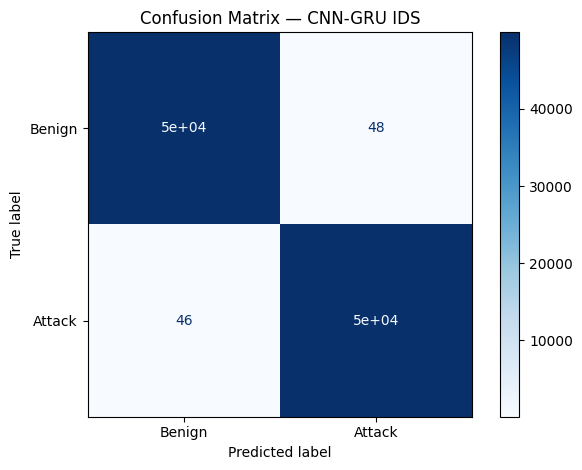

In [7]:
# ---- Confusion Matrix (computed from predictions) ----
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Benign', 'Attack'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — CNN-GRU IDS')
plt.tight_layout()
plt.show()

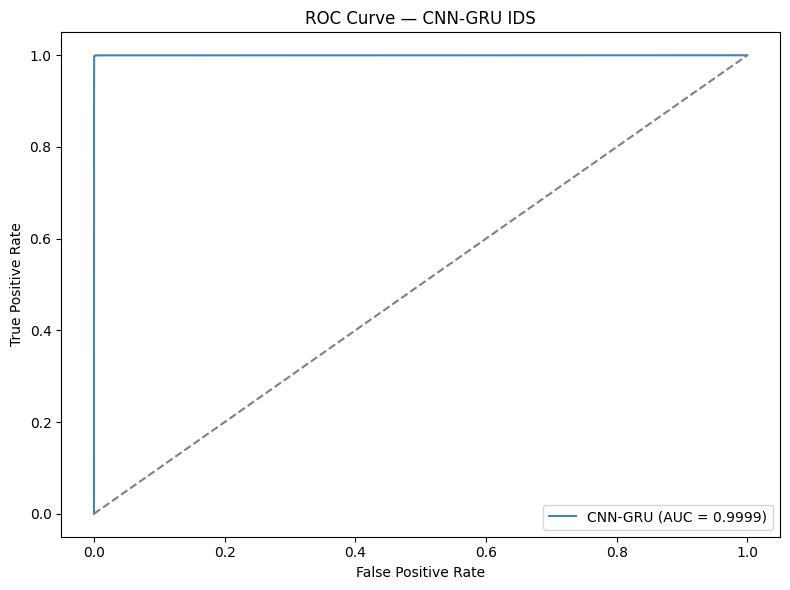

In [8]:
# ---- ROC Curve (binary) ----
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'CNN-GRU (AUC = {roc_auc:.4f})', color='steelblue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — CNN-GRU IDS')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

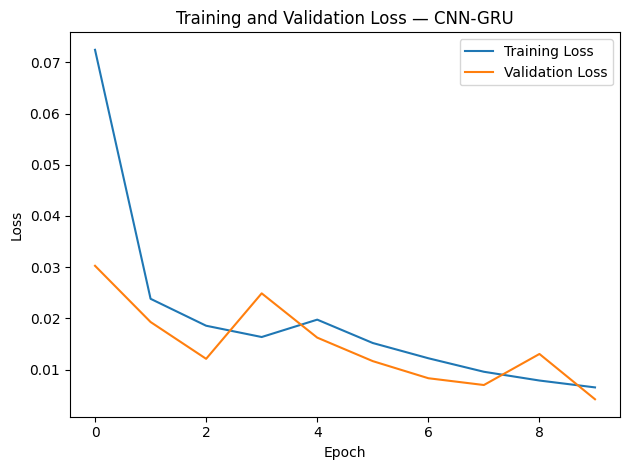

In [9]:
# ---- Training / Validation Loss Curve ----
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss — CNN-GRU')
plt.legend()
plt.tight_layout()
plt.show()

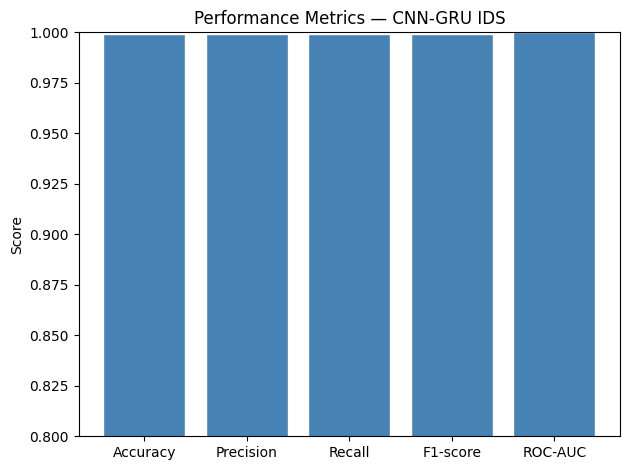

In [10]:

# ---- Metrics Bar Chart ----
metrics_dict = {
    'Accuracy':  accuracy,
    'Precision': precision,
    'Recall':    recall,
    'F1-score':  f1,
    'ROC-AUC':   roc_auc
}
plt.bar(metrics_dict.keys(), metrics_dict.values(), color='steelblue', edgecolor='white')
plt.ylim(0.8, 1.0)
plt.ylabel('Score')
plt.title('Performance Metrics — CNN-GRU IDS')
plt.tight_layout()
plt.show()


## 4. Autoencoder — Anomaly Detection

Trained **exclusively on benign traffic**. At inference, traffic with reconstruction error above the threshold is flagged as an attack.  
Threshold = 95th percentile of benign reconstruction errors.

In [11]:
# ---- Build Autoencoder ----
X_benign = X_train[y_train == 0]
print('Benign training samples:', X_benign.shape)

input_dim   = X_benign.shape[1]
ae_input    = Input(shape=(input_dim,))
encoded     = Dense(64, activation='relu')(ae_input)
encoded     = Dense(32, activation='relu')(encoded)
decoded     = Dense(64, activation='relu')(encoded)
decoded     = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=ae_input, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Benign training samples: (200000, 115)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 115)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 115)            │         7,475 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,091 (74.57 KB)

 Trainable params: 19,091 (74.57 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history_ae = autoencoder.fit(
    X_benign, X_benign,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3176 - val_loss: 0.0422
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0361 - val_loss: 0.0253
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0228 - val_loss: 0.0176
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0164 - val_loss: 0.0136
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0133 - val_loss: 0.0116
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0115 - val_loss: 0.0103
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0103 - val_loss: 0.0093
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0095 - val_loss: 0.0086
Epoch 9/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0088 - val_loss: 0.0081
Epoch 10/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0083 - val_loss: 0.0078


In [13]:
# ---- Threshold from benign reconstruction error ----
benign_recon = autoencoder.predict(X_benign)
benign_error = np.mean(np.square(X_benign - benign_recon), axis=1)
threshold    = np.percentile(benign_error, 95)
print(f'Anomaly threshold (95th pct of benign): {threshold:.6f}')

# ---- Evaluate on test set ----
X_test_recon = autoencoder.predict(X_test)
recon_error  = np.mean(np.square(X_test - X_test_recon), axis=1)

y_ae_pred = (recon_error > threshold).astype(int)
y_ae_true = (y_test > 0).astype(int)   # 1 = any attack, 0 = benign

ae_accuracy  = accuracy_score(y_ae_true, y_ae_pred)
ae_precision = precision_score(y_ae_true, y_ae_pred, zero_division=0)
ae_recall    = recall_score(y_ae_true, y_ae_pred, zero_division=0)
ae_f1        = f1_score(y_ae_true, y_ae_pred, zero_division=0)

print('Autoencoder Anomaly Detection (Benign vs Any Attack)')
print('-' * 50)
print(f'Accuracy : {ae_accuracy:.4f}')
print(f'Precision: {ae_precision:.4f}')
print(f'Recall   : {ae_recall:.4f}')
print(f'F1-score : {ae_f1:.4f}')

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
Anomaly threshold (95th pct of benign): 0.024798
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Autoencoder Anomaly Detection (Benign vs Any Attack)
--------------------------------------------------
Accuracy : 0.8333
Precision: 0.9332
Recall   : 0.7180
F1-score : 0.8116


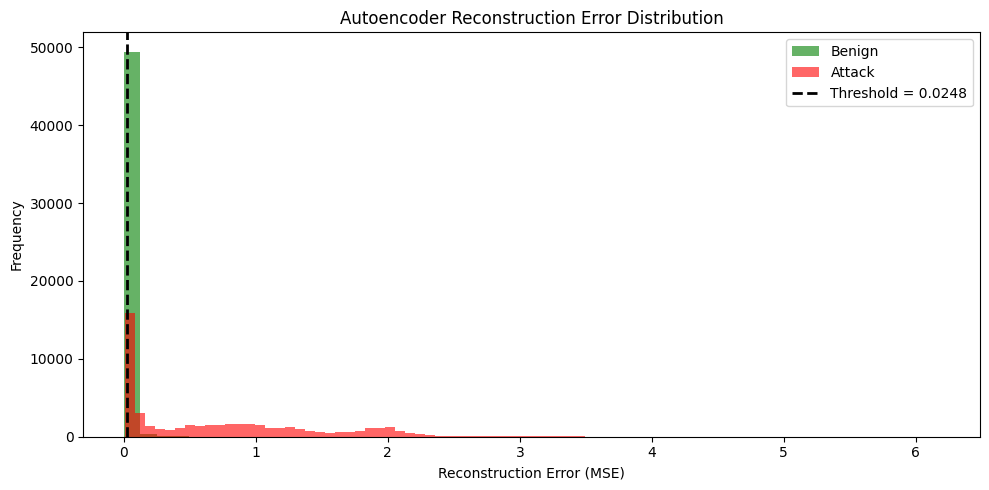

In [14]:
# ---- Reconstruction Error Distribution ----
plt.figure(figsize=(10, 5))
plt.hist(recon_error[y_ae_true == 0], bins=50, alpha=0.6, label='Benign', color='green')
plt.hist(recon_error[y_ae_true == 1], bins=50, alpha=0.6, label='Attack', color='red')
plt.axvline(threshold, color='black', linestyle='--', linewidth=2,
            label=f'Threshold = {threshold:.4f}')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Frequency')
plt.title('Autoencoder Reconstruction Error Distribution')
plt.legend()
plt.tight_layout()
plt.show()


## 5. Federated Learning — CNN-GRU (FedAvg)

Simulates **one client per physical IoT device** (up to 9 devices) using a **non-IID partition** — each client only sees traffic from its own device, which mirrors the real-world federated scenario.  
Each federated round: local training → collect weights → FedAvg aggregation → update global model.  
No raw data leaves the client — only weight updates are shared.


In [15]:

# ---- Partition training data by physical device (non-IID split) ----
# Each client = one real IoT device (identified by the numeric prefix in its filename)
unique_devices = np.unique(device_ids_train)
NUM_CLIENTS    = len(unique_devices)

client_data   = []
client_labels = []

for dev_id in unique_devices:
    mask = device_ids_train == dev_id
    client_data.append(X_train_r[mask])
    client_labels.append(y_train[mask])

print(f'Federated clients (one per physical IoT device): {NUM_CLIENTS}')
for i, dev_id in enumerate(unique_devices):
    u, c = np.unique(client_labels[i], return_counts=True)
    label_info = dict(zip(u.tolist(), c.tolist()))
    print(f'  Client {i+1} (Device {dev_id}): shape={client_data[i].shape}  labels={label_info}')


Federated clients (one per physical IoT device): 9
  Client 1 (Device 1): shape=(47710, 115, 1)  labels={0: 17878, 1: 29832}
  Client 2 (Device 2): shape=(29944, 115, 1)  labels={0: 4689, 1: 25255}
  Client 3 (Device 3): shape=(23836, 115, 1)  labels={0: 14114, 1: 9722}
  Client 4 (Device 4): shape=(91216, 115, 1)  labels={0: 62942, 1: 28274}
  Client 5 (Device 5): shape=(46171, 115, 1)  labels={0: 22490, 1: 23681}
  Client 6 (Device 6): shape=(58054, 115, 1)  labels={0: 35459, 1: 22595}
  Client 7 (Device 7): shape=(28542, 115, 1)  labels={0: 18711, 1: 9831}
  Client 8 (Device 8): shape=(41985, 115, 1)  labels={0: 16708, 1: 25277}
  Client 9 (Device 9): shape=(32542, 115, 1)  labels={0: 7009, 1: 25533}


In [16]:
def create_cnn_gru(input_shape):
    m = Sequential([
        Conv1D(64, 3, activation='relu', input_shape=input_shape),
        Dropout(0.3),
        GRU(64),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    m.compile(
        optimizer=Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return m

In [17]:

GLOBAL_ROUNDS = 3
LOCAL_EPOCHS  = 3

global_model_fed = create_cnn_gru(INPUT_SHAPE)

# Pre-compute each client's sample count for weighted averaging
client_sizes  = [len(client_data[i]) for i in range(NUM_CLIENTS)]
total_samples = sum(client_sizes)

for round_num in range(GLOBAL_ROUNDS):
    print(f'Federated Round {round_num + 1}/{GLOBAL_ROUNDS}')
    client_weights = []

    for i in range(NUM_CLIENTS):
        local_model = create_cnn_gru(INPUT_SHAPE)
        local_model.set_weights(global_model_fed.get_weights())
        local_model.fit(
            client_data[i], client_labels[i],
            epochs=LOCAL_EPOCHS,
            batch_size=256,
            verbose=0
        )
        client_weights.append(local_model.get_weights())
        print(f'  Client {i+1} trained ({client_sizes[i]} samples).')

    # FedAvg: weighted average proportional to each client's sample count
    # (unweighted mean is incorrect when clients have unequal data sizes)
    avg_weights = [
        sum(
            (client_sizes[i] / total_samples) * client_weights[i][layer]
            for i in range(NUM_CLIENTS)
        )
        for layer in range(len(client_weights[0]))
    ]
    global_model_fed.set_weights(avg_weights)
    print(f'  Global model updated.')

print('Federated training complete.')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Federated Round 1/3
  Client 1 trained (47710 samples).
  Client 2 trained (29944 samples).
  Client 3 trained (23836 samples).
  Client 4 trained (91216 samples).
  Client 5 trained (46171 samples).
  Client 6 trained (58054 samples).
  Client 7 trained (28542 samples).
  Client 8 trained (41985 samples).
  Client 9 trained (32542 samples).
  Global model updated.
Federated Round 2/3
  Client 1 trained (47710 samples).
  Client 2 trained (29944 samples).
  Client 3 trained (23836 samples).
  Client 4 trained (91216 samples).
  Client 5 trained (46171 samples).
  Client 6 trained (58054 samples).
  Client 7 trained (28542 samples).
  Client 8 trained (41985 samples).
  Client 9 trained (32542 samples).
  Global model updated.
Federated Round 3/3
  Client 1 trained (47710 samples).
  Client 2 trained (29944 samples).
  Client 3 trained (23836 samples).
  Client 4 trained (91216 samples).
  Client 5 trained (46171 samples).
  Client 6 trained (58054 samples).
  Client 7 trained (28542 sa

In [18]:
# ---- Evaluate Federated Model ----
y_fl_prob = global_model_fed.predict(X_test_r).ravel()
y_fl_pred = (y_fl_prob > 0.5).astype(int)

fl_accuracy  = accuracy_score(y_test, y_fl_pred)
fl_precision = precision_score(y_test, y_fl_pred, zero_division=0)
fl_recall    = recall_score(y_test,    y_fl_pred, zero_division=0)
fl_f1        = f1_score(y_test,        y_fl_pred, zero_division=0)
fl_roc       = roc_auc_score(y_test,   y_fl_prob)

print('Federated CNN-GRU Results')
print('-' * 35)
print(f'Accuracy : {fl_accuracy:.4f}')
print(f'Precision: {fl_precision:.4f}')
print(f'Recall   : {fl_recall:.4f}')
print(f'F1-score : {fl_f1:.4f}')
print(f'ROC-AUC  : {fl_roc:.4f}')

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step
Federated CNN-GRU Results
-----------------------------------
Accuracy : 0.9422
Precision: 0.8992
Recall   : 0.9961
F1-score : 0.9452
ROC-AUC  : 0.9954


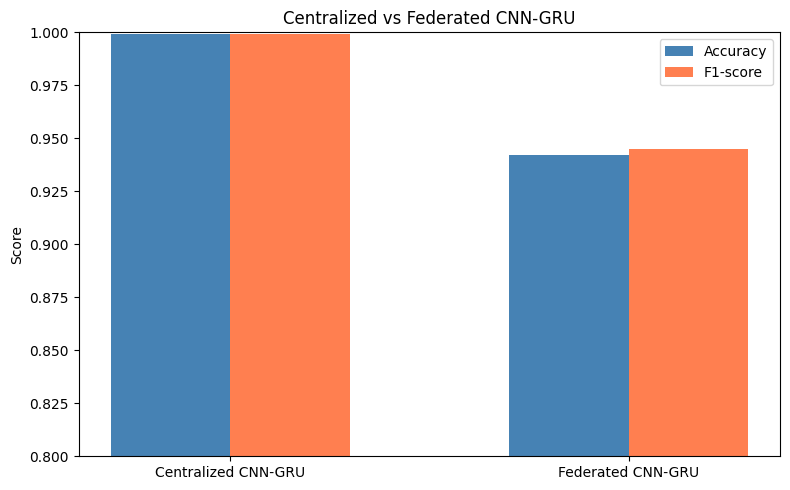

In [19]:
# ---- Centralized vs Federated Comparison ----
x      = np.arange(2)
width  = 0.3
labels = ['Centralized CNN-GRU', 'Federated CNN-GRU']

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, [accuracy,  fl_accuracy],  width, label='Accuracy',  color='steelblue')
ax.bar(x + width/2, [f1,        fl_f1],        width, label='F1-score',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.8, 1.0)
ax.set_ylabel('Score')
ax.set_title('Centralized vs Federated CNN-GRU')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Save Artifacts

All files are saved to `/kaggle/working/`.  
After clicking **Save & Run All**, they will appear as **Output** files you can download or reference in other notebooks.

| File | Contents |
|------|----------|
| `cnn_gru_ids.keras` | Centralized CNN-GRU weights + architecture |
| `federated_cnn_gru_ids.keras` | Federated (FedAvg) CNN-GRU |
| `autoencoder_ids.keras` | Autoencoder for anomaly detection |
| `scaler.pkl` | Fitted StandardScaler (must be applied before inference) |
| `ae_threshold.pkl` | Anomaly threshold value |
| `label_map.pkl` | `{0: 'Benign', 1: 'Attack'}` |


In [20]:
OUTPUT_DIR = '/kaggle/working'

# Centralized CNN-GRU
model.save(os.path.join(OUTPUT_DIR, 'cnn_gru_ids.keras'))
print('Saved: cnn_gru_ids.keras')

# Federated CNN-GRU
global_model_fed.save(os.path.join(OUTPUT_DIR, 'federated_cnn_gru_ids.keras'))
print('Saved: federated_cnn_gru_ids.keras')

# Autoencoder
autoencoder.save(os.path.join(OUTPUT_DIR, 'autoencoder_ids.keras'))
print('Saved: autoencoder_ids.keras')

# StandardScaler
with open(os.path.join(OUTPUT_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print('Saved: scaler.pkl')

# Autoencoder anomaly threshold
with open(os.path.join(OUTPUT_DIR, 'ae_threshold.pkl'), 'wb') as f:
    pickle.dump(float(threshold), f)
print('Saved: ae_threshold.pkl')

# Label map
label_map = {0: 'Benign', 1: 'Attack'}
with open(os.path.join(OUTPUT_DIR, 'label_map.pkl'), 'wb') as f:
    pickle.dump(label_map, f)
print('Saved: label_map.pkl')

print()
print('All artifacts saved to /kaggle/working/')
print('Run "Save & Run All" to persist them as Kaggle output files.')

Saved: cnn_gru_ids.keras
Saved: federated_cnn_gru_ids.keras
Saved: autoencoder_ids.keras
Saved: scaler.pkl
Saved: ae_threshold.pkl
Saved: label_map.pkl

All artifacts saved to /kaggle/working/
Run "Save & Run All" to persist them as Kaggle output files.


In [21]:

# ---- Export test set as CSV (for Streamlit demo) ----
# X_test_raw contains the original unscaled features so the app
# can demonstrate the full pipeline: upload → scale → predict.
test_export = pd.DataFrame(X_test_raw, columns=feature_cols)
test_export['label'] = y_test
test_export.to_csv(os.path.join(OUTPUT_DIR, 'test_samples.csv'), index=False)
print(f'Saved: test_samples.csv  ({test_export.shape[0]} rows, {len(feature_cols)} feature columns + label)')
print('Download this file from Kaggle Output and use it as input to the Streamlit demo app.')


Saved: test_samples.csv  (100000 rows, 115 feature columns + label)
Download this file from Kaggle Output and use it as input to the Streamlit demo app.


## 7. Inference Example

How to use the saved artifacts to classify new network traffic in another notebook or script.

In [22]:

# ============================================================
# Inference snippet — smoke-test using artifacts just saved
# to /kaggle/working/ in this same notebook.
#
# To use these artifacts in a DIFFERENT notebook, change
# ARTIFACT_DIR to:
#   '/kaggle/input/<your-output-dataset-slug>/'
# ============================================================
from tensorflow.keras.models import load_model

ARTIFACT_DIR = '/kaggle/working'

_model = load_model(os.path.join(ARTIFACT_DIR, 'cnn_gru_ids.keras'))
with open(os.path.join(ARTIFACT_DIR, 'scaler.pkl'), 'rb') as f:
    _scaler = pickle.load(f)
with open(os.path.join(ARTIFACT_DIR, 'label_map.pkl'), 'rb') as f:
    _label_map = pickle.load(f)

def predict_traffic(raw_features: np.ndarray) -> str:
    """Classify a single traffic sample.
    raw_features: 1-D array with the same N-BaIoT features (unscaled)
    Returns: 'Benign' or 'Attack'
    """
    scaled   = _scaler.transform(raw_features.reshape(1, -1))
    reshaped = scaled.reshape(1, scaled.shape[1], 1)
    prob     = _model.predict(reshaped, verbose=0).ravel()[0]
    return _label_map[int(prob > 0.5)]

# ---- Quick smoke-test with a sample from the test set ----
sample     = X_test[0]                             # already scaled (from preprocessing)
reshaped   = sample.reshape(1, len(sample), 1)
prob       = _model.predict(reshaped, verbose=0).ravel()[0]
prediction = _label_map[int(prob > 0.5)]
truth      = _label_map[int(y_test[0])]
print(f'Predicted: {prediction}  |  Ground truth: {truth}')


Predicted: Attack  |  Ground truth: Attack
